In [1]:
import ssl
import nltk

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Sekarang bisa download
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /Users/divaoncom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/divaoncom/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

2025-08-05 23:12:02,648 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggi

Error mcs=20, ms=5: Length of weights not compatible with specified axis.


2025-08-05 23:13:54,090 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Error mcs=20, ms=10: Length of weights not compatible with specified axis.


2025-08-05 23:14:23,094 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Error mcs=30, ms=5: Length of weights not compatible with specified axis.


2025-08-05 23:14:44,359 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Error mcs=30, ms=10: Length of weights not compatible with specified axis.
⚠ Tidak ditemukan model dengan noise ≤50%, menggunakan model dengan noise terkecil.


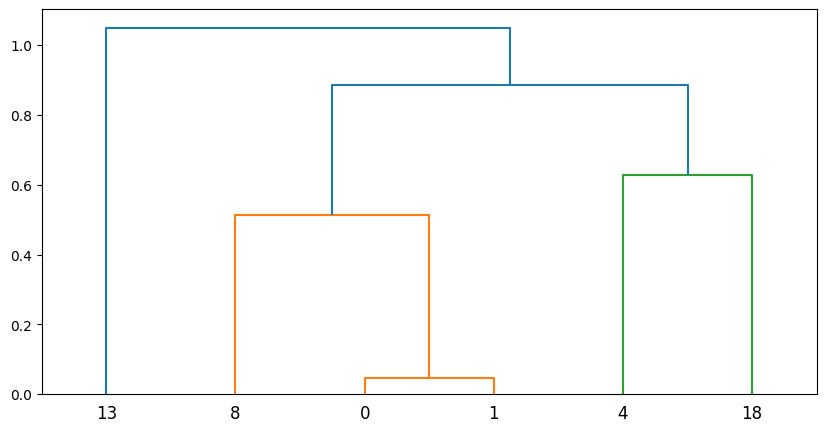

Persentase noise akhir: 57.57%
Total topik setelah merge otomatis: 15
Coherence C_v model terpilih: 0.3479
Davies-Bouldin Index model terpilih: 3.1420


In [12]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from hdbscan import HDBSCAN
from sklearn.metrics import davies_bouldin_score
from sentence_transformers import SentenceTransformer
from langdetect import detect, DetectorFactory
from sklearn.metrics.pairwise import cosine_similarity
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict
import matplotlib.pyplot as plt
from gensim.corpora.dictionary import Dictionary
from gensim.models import CoherenceModel
import warnings
import umap

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0
np.random.seed(42)

umap_model = umap.UMAP(n_neighbors=15, n_components=5, metric="cosine", random_state=42)

df = pd.read_csv("embedding_umap.csv")
df = df[df["cleaned_Reviews"].notnull() & df["cleaned_Reviews"].str.strip().astype(bool)]
df = df[df["cleaned_Reviews"].apply(lambda x: isinstance(x, str))]

# Tambahan: filter review terlalu pendek
df = df[df["cleaned_Reviews"].str.split().str.len() >= 5]

df["lang"] = df["cleaned_Reviews"].apply(lambda x: detect(x) if len(x.strip()) > 5 else "unknown")
df = df[df["lang"] == "en"]
docs = df["cleaned_Reviews"].tolist()

emb_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = emb_model.encode(docs, show_progress_bar=True)
rep_model = MaximalMarginalRelevance(diversity=0.3, top_n_words=30)

# Perluasan seed topic list
seed_topic_list = [
    ["graphics", "visual", "texture", "animation", "art", "rendering", "design", "lighting", "environment", "resolution"],
    ["performance", "fps", "frame", "lag", "stutter", "freeze", "optimization", "latency", "smooth", "crash"],
    ["sound", "audio", "music", "sfx", "voice", "soundtrack", "volume", "ambient", "effects"],
    ["mechanics", "gameplay", "controls", "movement", "combat", "interaction", "difficulty", "progression", "features"],
    ["story", "plot", "narrative", "dialogue", "cutscene", "lore", "writing", "quest", "ending", "twist"],
    ["character", "npc", "protagonist", "antagonist", "emotion", "personality", "backstory", "development"],
    ["ui", "menu", "hud", "interface", "usability", "navigation", "accessibility", "button", "layout"]
]

results = []
for mcs in [10, 20, 30]:
    for ms in [5, 10]:
        try:
            hdb = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean", prediction_data=True)
            model = BERTopic(
                umap_model=umap_model,
                hdbscan_model=hdb,
                embedding_model=emb_model,
                representation_model=rep_model,
                seed_topic_list=seed_topic_list,
                calculate_probabilities=True,
                verbose=False
            )
            topics, probs = model.fit_transform(docs, embeddings)
            reduced = model.reduce_outliers(docs, topics, strategy="probabilities", probabilities=probs, threshold=0.1)
            model.update_topics(docs, topics=reduced, representation_model=rep_model)
            model = model.reduce_topics(docs, nr_topics=20)

            labels = np.array(model.topics_)
            valid = labels != -1
            dbi = davies_bouldin_score(embeddings[valid], labels[valid]) if valid.sum() > 1 else np.nan
            noise = round(1 - valid.mean(), 2)

            tokenized = [d.split() for d in docs]
            dict_ = Dictionary(tokenized)
            topic_words = [[w for w, _ in model.get_topic(t)] for t in model.get_topic_freq()["Topic"] if t != -1 and model.get_topic(t)]
            cv = CoherenceModel(topics=topic_words, texts=tokenized, dictionary=dict_, coherence='c_v').get_coherence()

            results.append((dbi, noise, cv, model, labels))
        except Exception as e:
            print(f"Error mcs={mcs}, ms={ms}: {e}")
            continue

if any(r[1] <= 0.5 for r in results):
    cands = [r for r in results if r[1] <= 0.5]
else:
    print("⚠ Tidak ditemukan model dengan noise ≤50%, menggunakan model dengan noise terkecil.")
    cands = results
best = sorted(cands, key=lambda x: (x[0], -x[2]))[0]
final_model, final_topics = best[3], np.array(best[4])
df["topic"] = final_topics

# Hitung centroid dari semua kata dalam seed_topic_list
seed_words = sum(seed_topic_list, [])  # flatten
seed_embeddings = emb_model.encode(seed_words)
seed_centroid = np.mean(seed_embeddings, axis=0)

# Ukur similarity tiap topik ke seed centroid
topic_centroids = final_model.topic_embeddings_
similarities = cosine_similarity([seed_centroid], topic_centroids)[0]
threshold = 0.4  # simpan topik yang cukup dekat ke tema game

valid_topics = [i for i, sim in enumerate(similarities) if sim >= threshold and i in final_model.get_topic_info()["Topic"].tolist()]
topic_centroids = [topic_centroids[i] for i in valid_topics]

# Auto merge berdasarkan similarity antar topik
dist = 1 - cosine_similarity(topic_centroids)
link = sch.linkage(dist, method="ward")

plt.figure(figsize=(10,5))
sch.dendrogram(link, labels=valid_topics)
plt.show()

ids = fcluster(link, t=1, criterion='distance')
cm = defaultdict(list)
for t, i in zip(valid_topics, ids):
    cm[i].append(t)
to_merge = [g for g in cm.values() if len(g) > 1]
final_model.merge_topics(docs, topics_to_merge=to_merge)

df["topic"] = final_model.topics_
df.to_csv("hasil_topic_assignment_automerged.csv", index=False)

kw = []
for t in final_model.get_topic_info()["Topic"]:
    if t == -1:
        continue
    topic_words = final_model.get_topic(t)
    if not topic_words:
        continue
    keywords = ", ".join([w for w, _ in topic_words])
    kw.append({"topic": t, "keywords": keywords})
keywords_df = pd.DataFrame(kw)
keywords_df.to_csv("daftar_topik_keywords_automerged.csv", index=False)

arr = np.array(final_model.topics_)
noise_ct = int((arr == -1).sum())
noise_pct = round(noise_ct / len(arr) * 100, 2)
print(f"Persentase noise akhir: {noise_pct}%")
print(f"Total topik setelah merge otomatis: {len(keywords_df)}")
print(f"Coherence C_v model terpilih: {best[2]:.4f}")
print(f"Davies-Bouldin Index model terpilih: {best[0]:.4f}")
